# Diagnostic de cohérence CRM, ERPs : Qualité des données de référence Tiers



## Configuration & connexion aux sources de données

In [1]:
import os

DB_CONFIG_1 = {
    "user": os.getenv("DB_USER_1", "cas"),
    "password": os.getenv("DB_PASSWORD_1", "tiger"),
    "dsn": os.getenv("DB_DSN_1", "10.1.201.214/erpv6"),
    "schemas": ["CAS"]
}

DB_CONFIG_2 = {
    "user": os.getenv("DB_USER_2", "cmgp"),
    "password": os.getenv("DB_PASSWORD_2", "tiger"),
    "dsn": os.getenv("DB_DSN_2", "193.100.100.214/erpv6"),
    "schemas": ["CMGP", "SICDA","PHILEA"]
}

DB_CONFIG_CRM = {
    "user": os.getenv("DB_USER_CRM", "qlik"),
    "password": os.getenv("DB_PASSWORD_CRM", "qlik"),
    "dsn": os.getenv("DB_DSN_CRM", "193.100.100.102/erpv6"),
    "central_schema": "CRM"
}

FILIALES = DB_CONFIG_1["schemas"] + DB_CONFIG_2["schemas"]

print(f"Filiales configurées : {FILIALES}")

Filiales configurées : ['CAS', 'CMGP', 'SICDA', 'PHILEA']


In [2]:
import numpy as np
import pandas as pd
from sqlalchemy import create_engine
import oracledb

try:
    oracledb.init_oracle_client()
except Exception as e:
    print(f"Oracle Client init warning (Thin mode will be used if failing): {e}")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

def get_prod_engine():
    engines = {}
    
    dsn_crm = f"oracle+oracledb://{DB_CONFIG_CRM['user']}:{DB_CONFIG_CRM['password']}@{DB_CONFIG_CRM['dsn']}"
    engines["CRM"] = create_engine(dsn_crm)
    
    dsn_1 = f"oracle+oracledb://{DB_CONFIG_1['user']}:{DB_CONFIG_1['password']}@{DB_CONFIG_1['dsn']}"
    engine_1 = create_engine(dsn_1)
    for schema in DB_CONFIG_1["schemas"]:
        engines[schema] = engine_1
        
    dsn_2 = f"oracle+oracledb://{DB_CONFIG_2['user']}:{DB_CONFIG_2['password']}@{DB_CONFIG_2['dsn']}"
    engine_2 = create_engine(dsn_2)
    for schema in DB_CONFIG_2["schemas"]:
        engines[schema] = engine_2

    return engines

conn = get_prod_engine()

def run_sql(query, params=None):
    engine = conn["CRM"]
    query_lower = query.lower()
    for fil in FILIALES:
        if f"{fil.lower()}_bpcustomer" in query_lower or f"{fil}.BPCUSTOMER" in query.upper():
            engine = conn[fil]
            break
            
    query = query.replace("crm_tiers_societe", f"{DB_CONFIG_CRM['central_schema']}.TIERS_SOCIETE")
    query = query.replace("crm_tiers", f"{DB_CONFIG_CRM['central_schema']}.TIERS")
    for fil in FILIALES:
        query = query.replace(f"{fil.lower()}_bpcustomer", f"{fil}.BPCUSTOMER")
        
    try:
        return pd.read_sql_query(query, engine, params=params)
    except Exception as e:
        print(f"SQL Error on {engine}: {e}\nQuery: {query}")
        return pd.DataFrame()

## Tiers CRM sans enregistrement associé dans `tiers_societe`

In [3]:

q_point1 = """
SELECT t.ID_CODE_TIERS_CRM,
       t.TIERS_CODE,
       t.ID_RAISON_SOCIALE,
       t.GST_STATUT_TIERS,
       t.SEGMENT,
       t.PAYS
FROM crm_tiers t
LEFT JOIN crm_tiers_societe ts
       ON t.ID_CODE_TIERS_CRM = ts.ID_CODE_TIERS_CRM
WHERE ts.ID_CODE_TIERS_CRM IS NULL
ORDER BY t.ID_CODE_TIERS_CRM
"""

df_tiers_sans_societe = run_sql(q_point1)

total_tiers = run_sql("SELECT COUNT(*) AS n FROM crm_tiers")["n"].iloc[0]
nb_sans_societe = len(df_tiers_sans_societe)
taux_sans_societe = 100 * nb_sans_societe / total_tiers if total_tiers else 0

print(f"Tiers CRM total            : {total_tiers}")
print(f"Tiers sans tiers_societe   : {nb_sans_societe}  ({taux_sans_societe:.2f} %)")
display(df_tiers_sans_societe.head(20))


Tiers CRM total            : 10753
Tiers sans tiers_societe   : 102  (0.95 %)


,id_code_tiers_crm,tiers_code,id_raison_sociale,gst_statut_tiers,segment,pays
0,4385,004183,CHAMI JAOUAD,1,None,MA
1,4738,004536,AUEA SIDI LHADI,1,None,MA
2,5057,004855,ASSOCIATION UNITE ET CONSTRUCTION,1,None,MA
3,5184,004982,PEPINIERES DE LATLAS,1,None,MA
4,5361,005159,SAFINA,1,None,MA
5,5381,005179,M.BOURIMECH NOURDDINE,1,None,MA
6,5431,005229,ABDELAZIZ HAMID LAH,1,None,MA
7,5710,005508,M PARTNERS S.A.R.L,1,None,MA
8,6376,006174,AUEA AL KHAYR,1,None,MA
9,6380,006178,M MILOUD EL AALEJ,1,None,MA


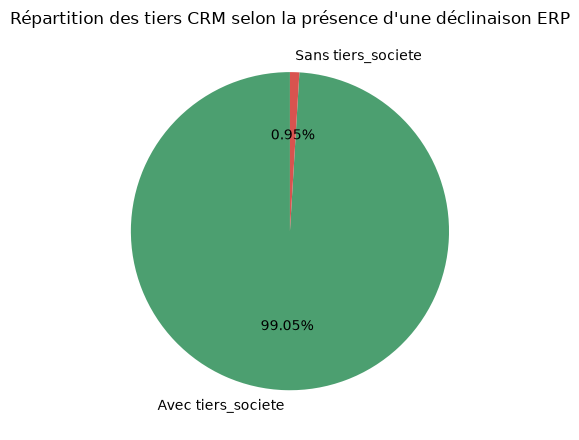

In [4]:
import matplotlib.pyplot as plt

nb_avec_societe = total_tiers - nb_sans_societe
sizes = [nb_avec_societe, nb_sans_societe]

fig, ax = plt.subplots(figsize=(4.5, 4.5))

ax.pie(sizes, labels=["Avec tiers_societe", "Sans tiers_societe"], autopct="%1.2f%%",
       colors=["#4C9F70", "#D9534F"], startangle=90)

ax.set_title("Répartition des tiers CRM selon la présence d'une déclinaison ERP")
plt.tight_layout()
plt.show()

## Lignes `tiers_societe` sans tiers parent (orphelines)

In [5]:

q_point2 = """
SELECT ts.ID_CODE_TIERS_CRM,
       ts.id_code_societe,
       ts.ID_CODE_TIERS_ERP_1,
       ts.ID_LIB_TIERS_ERP,
       ts.SEGMENT
FROM crm_tiers_societe ts
LEFT JOIN crm_tiers t
       ON ts.ID_CODE_TIERS_CRM = t.ID_CODE_TIERS_CRM
WHERE t.ID_CODE_TIERS_CRM IS NULL
ORDER BY ts.ID_CODE_TIERS_CRM
"""

df_ts_orphelines = run_sql(q_point2)

total_ts = run_sql("SELECT COUNT(*) AS n FROM crm_tiers_societe")["n"].iloc[0]
nb_orphelines = len(df_ts_orphelines)
taux_orphelines = 100 * nb_orphelines / total_ts if total_ts else 0

print(f"Lignes tiers_societe total     : {total_ts}")
print(f"Lignes orphelines (sans tiers) : {nb_orphelines}  ({taux_orphelines:.2f} %)")

Lignes tiers_societe total     : 14623
Lignes orphelines (sans tiers) : 0  (0.00 %)


## Clients CRM effectivement créés dans les ERP (couverture CRM vers ERPs)

In [6]:
rows_couverture = []
detail_couverture = {}

for fil in FILIALES:
    q_crm = f"""
    SELECT ts.ID_CODE_TIERS_ERP_1,
           ts.ID_CODE_TIERS_CRM,
           t.TIERS_CODE,
           ts.ID_LIB_TIERS_ERP
    FROM crm_tiers_societe ts
    INNER JOIN crm_tiers t ON ts.ID_CODE_TIERS_CRM = t.ID_CODE_TIERS_CRM
    WHERE ts.id_code_societe = '{fil}'
      AND ts.ID_CODE_TIERS_ERP_1 IS NOT NULL
    """
    df_crm_fil = run_sql(q_crm)

    q_erp = f"""
    SELECT BPCINV_0 FROM {fil.lower()}.bpcustomer
    """
    df_erp_fil = run_sql(q_erp)

    erp_codes = set(
        df_erp_fil["bpcinv_0"].dropna().astype(str).str.strip().str.upper()
    )
    
    crm_codes_clean = df_crm_fil["id_code_tiers_erp_1"].astype(str).str.strip().str.upper()

    df_crm_fil["present_dans_erp"] = crm_codes_clean.isin(erp_codes).astype(int)

    nb_attendu = len(df_crm_fil)
    nb_present = int(df_crm_fil["present_dans_erp"].sum())
    taux = round(100 * nb_present / nb_attendu, 2) if nb_attendu else 0

    rows_couverture.append({
        "Filiale": fil,
        "Clients attendus (tiers_societe)": nb_attendu,
        "Clients trouvés dans bpcustomer": nb_present,
        "Taux de couverture (%)": taux,
    })
    detail_couverture[fil] = df_crm_fil

df_couverture_crm_erp = pd.DataFrame(rows_couverture)
display(df_couverture_crm_erp)

,Filiale,Clients attendus (tiers_societe),Clients trouvés dans bpcustomer,Taux de couverture (%)
0,CAS,6227,6217,99.84
1,CMGP,6629,6610,99.71
2,SICDA,792,782,98.74
3,PHILEA,702,700,99.72


## Clients présents dans le CRM mais absents des ERP

In [7]:
frames_manquants = []
for fil in FILIALES:
    df = detail_couverture[fil]
    manquants = df[df["present_dans_erp"] == 0].copy()
    manquants.insert(0, "Filiale", fil)
    frames_manquants.append(manquants.drop(columns=["present_dans_erp"]))

df_crm_absents_erp = pd.concat(frames_manquants, ignore_index=True) if frames_manquants else pd.DataFrame()

print(f"Total de codes CRM absents de l'ERP correspondant : {len(df_crm_absents_erp)}")
display(df_crm_absents_erp.head(50))

Total de codes CRM absents de l'ERP correspondant : 41


,Filiale,id_code_tiers_erp_1,id_code_tiers_crm,tiers_code,id_lib_tiers_erp
0,CAS,DR00MAL1008164,8367,008164,PHYTO EL KHDIMI
1,CAS,DA00MAL1008162,8365,008162,DOMAINE ABDELWAHAD RADI
2,CAS,DA00MAL1004205,4407,004205,EL BOUT BRAHIM
3,CAS,DA00MAS1009121,9324,009121,LIJJI RACHID
4,CAS,DA00MAR1012908,13218,012908,TARRICHT
5,CAS,DA00MAM1013381,13947,013381,ZINEDDINE YASSINE
6,CAS,DR00MAL1004474,4676,004474,ESSOUSI ALLAL
7,CAS,DA00MAR1013029,13371,013029,MOHAMED AMINE JEBABRA
8,CAS,DR01MAS1000953,1155,000953,PROPHYTO HAKAM
9,CAS,DR00MAM1009599,9814,009599,NaN


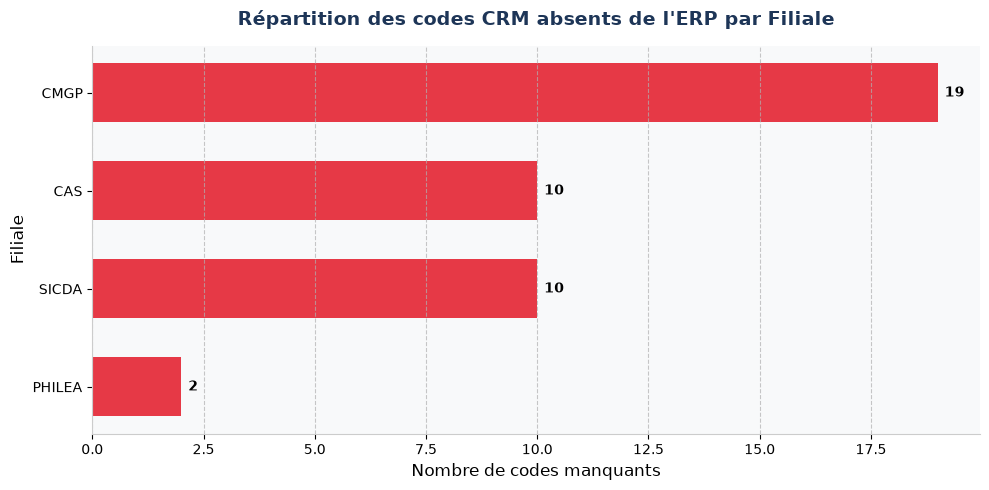

In [8]:
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

frames_manquants = []
for fil in FILIALES:
    df = detail_couverture[fil]
    manquants = df[df["present_dans_erp"] == 0].copy()
    manquants.insert(0, "Filiale", fil)
    frames_manquants.append(manquants.drop(columns=["present_dans_erp"]))

df_crm_absents_erp = pd.concat(frames_manquants, ignore_index=True) if frames_manquants else pd.DataFrame()
total_manquants = len(df_crm_absents_erp)

if total_manquants > 0:
    df_repartition = df_crm_absents_erp["Filiale"].value_counts().reset_index()
    df_repartition.columns = ["Filiale", "Codes Manquants"]
    df_repartition["Part (%)"] = ((df_repartition["Codes Manquants"] / total_manquants) * 100).round(1)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_facecolor('#f8f9fa')
    fig.patch.set_facecolor('#ffffff')
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    
    bars = ax.barh(df_repartition["Filiale"], df_repartition["Codes Manquants"], color='#e63946', height=0.6)
    ax.invert_yaxis()
    
    ax.bar_label(bars, padding=5, weight='bold')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    
    plt.title("Répartition des codes CRM absents de l'ERP par Filiale", fontsize=14, pad=15, weight='bold', color='#1d3557')
    plt.xlabel("Nombre de codes manquants", fontsize=12)
    plt.ylabel("Filiale", fontsize=12)
    plt.tight_layout()
    plt.show()


## Clients présents dans les ERPs mais absents du CRM (ERPs vers CRM)

In [21]:
frames_erp_abs = []
rows_recap_erp = []

for fil in FILIALES:
    q_erp = f"""
    SELECT BPCINV_0 AS code_erp, BPCNAM_0 AS nom_client_erp
    FROM {fil.lower()}.bpcustomer
    WHERE = 2
    """
    df_erp_fil = run_sql(q_erp)

    q_crm = f"""
    SELECT ts.ID_CODE_TIERS_ERP_1
    FROM crm_tiers_societe ts
    WHERE ts.ID_CODE_SOCIETE = '{fil}'
    """
    df_crm_fil = run_sql(q_crm)

    crm_codes = set(df_crm_fil["id_code_tiers_erp_1"].dropna().astype(str).str.strip())
    mask_absent = ~df_erp_fil["code_erp"].astype(str).str.strip().isin(crm_codes)
    df_absent = df_erp_fil[mask_absent].copy()
    df_absent.insert(0, "Filiale", fil)
    frames_erp_abs.append(df_absent)

    nb_erp = len(df_erp_fil)
    nb_sans_crm = len(df_absent)
    taux = round(100 * nb_sans_crm / nb_erp, 2) if nb_erp else 0
    rows_recap_erp.append({
        "Filiale": fil,
        "Clients dans bpcustomer": nb_erp,
        "Sans correspondance CRM": nb_sans_crm,
        "Taux (%)": taux,
        "Taux cible (%)": "0.0",
    })

df_erp_absents_crm = pd.concat(frames_erp_abs, ignore_index=True) if frames_erp_abs else pd.DataFrame()
df_recap_erp_absents_crm = pd.DataFrame(rows_recap_erp)
display(df_recap_erp_absents_crm)
#display(df_erp_absents_crm.head(5))


,Filiale,Clients dans bpcustomer,Sans correspondance CRM,Taux (%),Taux cible (%)
0,CAS,8455,2238,26.47,0.0
1,CMGP,15750,9140,58.03,0.0
2,SICDA,1183,391,33.05,0.0
3,PHILEA,1841,1141,61.98,0.0


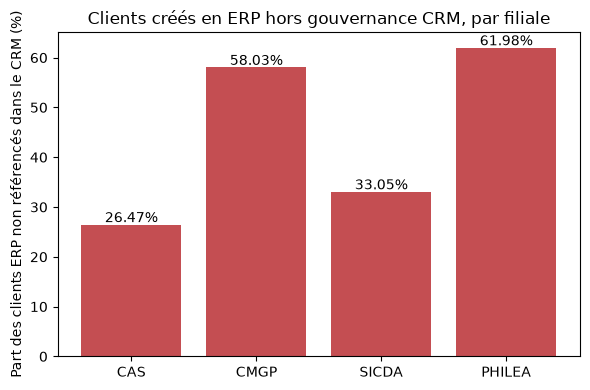

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(df_recap_erp_absents_crm["Filiale"], df_recap_erp_absents_crm["Taux (%)"], color="#C44E52")
ax.set_ylabel("Part des clients ERP non référencés dans le CRM (%)")
ax.set_title("Clients créés en ERP hors gouvernance CRM, par filiale")
for i, v in enumerate(df_recap_erp_absents_crm["Taux (%)"]):
    ax.text(i, v + 0.5, f"{v}%", ha="center")
plt.tight_layout()
plt.show()

In [11]:
from IPython.display import display, Markdown
total_erp_sans_crm = len(df_erp_absents_crm)
display(Markdown(f"""
**Synthèse**

- **{total_erp_sans_crm} clients ERP**, toutes filiales confondues, n'ont aucune correspondance dans le CRM.
- La filiale la plus concernée est **{df_recap_erp_absents_crm.loc[df_recap_erp_absents_crm['Taux (%)'].idxmax(), 'Filiale']}**.
"""))



**Synthèse**

- **12910 clients ERP**, toutes filiales confondues, n'ont aucune correspondance dans le CRM.
- La filiale la plus concernée est **PHILEA**.


## Cohérence des codes ERP générés (suffixe)

In [12]:
q_point6 = """
SELECT ts.ID_CODE_TIERS_CRM,
       t.TIERS_CODE,
       ts.ID_CODE_SOCIETE,
       ts.SEGMENT,
       ts.ID_CODE_TIERS_ERP_1
FROM crm_tiers_societe ts
INNER JOIN crm_tiers t ON ts.ID_CODE_TIERS_CRM = t.ID_CODE_TIERS_CRM
"""

df_codes = run_sql(q_point6)

def check_code(row):
    
    code_erp = str(row["id_code_tiers_erp_1"]).strip().upper()
    
    val_tiers = row["tiers_code"]
    if isinstance(val_tiers, float):  
        val_tiers = int(val_tiers)
    
    tiers_code_attendu = str(val_tiers).strip().zfill(6).upper()
    
    suffixe_erp = code_erp[-6:]
    
    if suffixe_erp == tiers_code_attendu:
        return "Conforme"
    else:
        return "Suffixe non conforme"

df_codes["statut_conformite"] = df_codes.apply(check_code, axis=1)


df_conformite = (
    df_codes.groupby(["id_code_societe", "statut_conformite"])
    .size()
    .unstack(fill_value=0)
)
display(df_conformite)

nb_non_conformes = int((df_codes["statut_conformite"] != "Conforme").sum())
taux_conformite = 100 * (len(df_codes) - nb_non_conformes) / len(df_codes) if len(df_codes) else 0
print(f"\nCodes ERP analysés   : {len(df_codes)}")
print(f"Codes non conformes  : {nb_non_conformes}  ({100 - taux_conformite:.2f} %)")
print(f"Taux de conformité   : {taux_conformite:.2f} %")

df_codes_anomalies = df_codes[df_codes["statut_conformite"] != "Conforme"]
#display(df_codes_anomalies.head(20))

statut_conformite,Conforme
id_code_societe,
CAS,6227
CMGP,6629
PHILEA,702
SICDA,792
SICDA3,273



Codes ERP analysés   : 14623
Codes non conformes  : 0  (0.00 %)
Taux de conformité   : 100.00 %


## Anomalies de synchronisation entre les différents systèmes

In [13]:
anomalies_consolidees = [
    {"Type d'anomalie": "Tiers CRM sans tiers_societe", "Périmètre": "CRM (global)", "Volume": nb_sans_societe},
    {"Type d'anomalie": "Lignes tiers_societe orphelines", "Périmètre": "CRM (global)", "Volume": nb_orphelines},
]
for fil in FILIALES:
    anomalies_consolidees.append({
        "Type d'anomalie": "Clients CRM absents de l'ERP",
        "Périmètre": fil,
        "Volume": int((df_crm_absents_erp["Filiale"] == fil).sum()) if len(df_crm_absents_erp) else 0,
    })
for fil in FILIALES:
    anomalies_consolidees.append({
        "Type d'anomalie": "Clients ERP absents du CRM",
        "Périmètre": fil,
        "Volume": int((df_erp_absents_crm["Filiale"] == fil).sum()) if len(df_erp_absents_crm) else 0,
    })
for fil in FILIALES:
    anomalies_consolidees.append({
        "Type d'anomalie": "Codes ERP non conformes (suffixe)",
        "Périmètre": fil,
        "Volume": int(((df_codes["id_code_societe"] == fil) & (df_codes["statut_conformite"] != "Conforme")).sum()),
    })

df_anomalies_consolidees = pd.DataFrame(anomalies_consolidees).sort_values("Volume", ascending=False)
display(df_anomalies_consolidees)

total_anomalies = df_anomalies_consolidees["Volume"].sum()
print(f"\nVolume total d'anomalies détectées (tous types, toutes filiales) : {total_anomalies}")

,Type d'anomalie,Périmètre,Volume
7,Clients ERP absents du CRM,CMGP,9140
6,Clients ERP absents du CRM,CAS,2238
9,Clients ERP absents du CRM,PHILEA,1141
8,Clients ERP absents du CRM,SICDA,391
0,Tiers CRM sans tiers_societe,CRM (global),102
3,Clients CRM absents de l'ERP,CMGP,19
2,Clients CRM absents de l'ERP,CAS,10
4,Clients CRM absents de l'ERP,SICDA,10
5,Clients CRM absents de l'ERP,PHILEA,2
1,Lignes tiers_societe orphelines,CRM (global),0



Volume total d'anomalies détectées (tous types, toutes filiales) : 13053


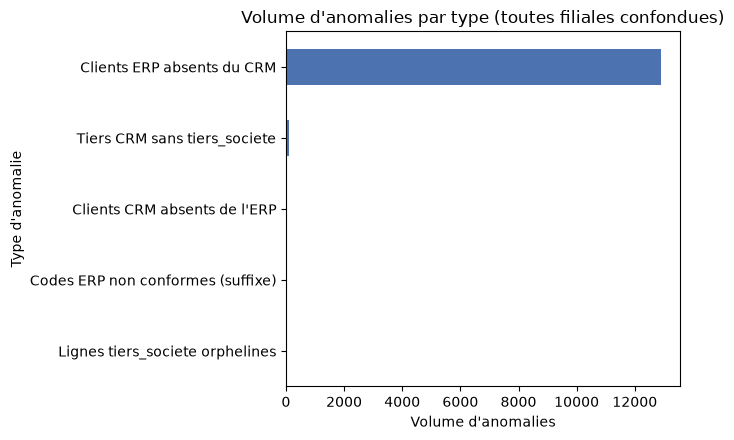

In [14]:
synth_par_type = df_anomalies_consolidees.groupby("Type d'anomalie")["Volume"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4.5))
synth_par_type.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Volume d'anomalies")
ax.set_title("Volume d'anomalies par type (toutes filiales confondues)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Indicateurs de couverture et de qualité des données

In [15]:
kpis = []
taux_moyen_couverture = df_couverture_crm_erp["Taux de couverture (%)"].mean()

kpis.append({"Indicateur": "Taux de tiers CRM avec au moins une déclinaison tiers_societe",
             "Valeur": f"{100 - taux_sans_societe:.2f} %"})
kpis.append({"Indicateur": "Taux de lignes tiers_societe orphelines",
             "Valeur": f"{taux_orphelines:.2f} %"})
kpis.append({"Indicateur": "Taux de couverture CRM -> ERP (moyenne toutes filiales)",
             "Valeur": f"{taux_moyen_couverture:.2f} %"})
kpis.append({"Indicateur": "Taux global de conformité des codes ERP (suffixe)",
             "Valeur": f"{taux_conformite:.2f} %"})
kpis.append({"Indicateur": "Nombre de clients ERP sans correspondance CRM (toutes filiales)",
             "Valeur": str(total_erp_sans_crm)})
kpis.append({"Indicateur": "Nombre total d'anomalies de synchronisation détectées",
             "Valeur": str(int(total_anomalies))})

for fil in FILIALES:
    couv = df_couverture_crm_erp.loc[df_couverture_crm_erp["Filiale"] == fil, "Taux de couverture (%)"].iloc[0]
    kpis.append({"Indicateur": f"Taux de couverture CRM -> ERP : {fil}", "Valeur": f"{couv} %"})

df_kpis = pd.DataFrame(kpis)

with pd.option_context('display.max_colwidth', None):
    display(df_kpis.style.set_properties(**{'text-align': 'left'}))

,Indicateur,Valeur
0,Taux de tiers CRM avec au moins une déclinaison tiers_societe,99.05 %
1,Taux de lignes tiers_societe orphelines,0.00 %
2,Taux de couverture CRM -> ERP (moyenne toutes filiales),99.50 %
3,Taux global de conformité des codes ERP (suffixe),100.00 %
4,Nombre de clients ERP sans correspondance CRM (toutes filiales),12910
5,Nombre total d'anomalies de synchronisation détectées,13053
6,Taux de couverture CRM -> ERP : CAS,99.84 %
7,Taux de couverture CRM -> ERP : CMGP,99.71 %
8,Taux de couverture CRM -> ERP : SICDA,98.74 %
9,Taux de couverture CRM -> ERP : PHILEA,99.72 %


## Complétude des données : Table `crm_tiers`
Analyse de la qualité de remplissage générale et détaillée par colonne.

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import seaborn as sns

df_tiers = run_sql("SELECT * FROM crm_tiers")

total_rows = len(df_tiers)

if total_rows > 0:
    completeness = []
    total_cells = total_rows * len(df_tiers.columns)
    total_non_null = 0
    
    for col in df_tiers.columns:
        # Traitement spécifique: considérer les chaines vides/espaces comme nuls si on veut être strict,
        # mais utilisons le standard (None/NaN)
        non_null_count = df_tiers[col].replace(r'^\s*$', np.nan, regex=True).count()
        total_non_null += non_null_count
        null_count = total_rows - non_null_count
        completion_rate = (non_null_count / total_rows) * 100
        
        completeness.append({
            "Colonne": col,
            "Renseignés": non_null_count,
            "Vides (Null)": null_count,
            "Taux de complétude (%)": round(completion_rate, 2)
        })
        
    df_comp_tiers = pd.DataFrame(completeness)
    df_comp_tiers = df_comp_tiers.sort_values("Taux de complétude (%)", ascending=False).reset_index(drop=True)
    general_completeness = (total_non_null / total_cells) * 100
    
    display(HTML(f"<h3>Complétude Générale de la table crm_tiers : <span style='color: {'green' if general_completeness > 80 else 'orange'};'>{general_completeness:.2f}%</span></h3>"))
    display(HTML(f"<p><b>{total_rows}</b> enregistrements analysés sur <b>{len(df_tiers.columns)}</b> colonnes.</p>"))
    
    display(HTML("<h4>Détail de complétude par colonne :</h4>"))
    display(df_comp_tiers.style.background_gradient(cmap='RdYlGn', subset=['Taux de complétude (%)'], vmin=0, vmax=100)\
            .format({"Taux de complétude (%)": "{:.2f}%"}))
    
    plt.figure(figsize=(14, 5))
    # Utilisation d'une palette en fonction de la valeur
    norm = plt.Normalize(0, 100)
    cmap = plt.get_cmap("RdYlGn")
    colors = [cmap(norm(val)) for val in df_comp_tiers['Taux de complétude (%)']]
    
    sns.barplot(data=df_comp_tiers, x='Colonne', y='Taux de complétude (%)', palette=colors)
    plt.title('Taux de complétude par colonne - crm_tiers')
    plt.xticks(rotation=90)
    plt.ylim(0, 105)
    plt.tight_layout()
    plt.show()
else:
    print("Table crm_tiers vide ou introuvable.")


## Complétude des données : Table `crm_tiers_societe`
Analyse de la qualité de remplissage générale et détaillée par colonne.

In [ ]:
df_tiers_societe = run_sql("SELECT * FROM crm_tiers_societe")

total_rows_soc = len(df_tiers_societe)

if total_rows_soc > 0:
    completeness_soc = []
    total_cells_soc = total_rows_soc * len(df_tiers_societe.columns)
    total_non_null_soc = 0
    
    for col in df_tiers_societe.columns:
        # Remplacer les chaines vides (espaces) par NaN pour un compte réaliste
        non_null_count = df_tiers_societe[col].replace(r'^\s*$', np.nan, regex=True).count()
        total_non_null_soc += non_null_count
        null_count = total_rows_soc - non_null_count
        completion_rate = (non_null_count / total_rows_soc) * 100
        
        completeness_soc.append({
            "Colonne": col,
            "Renseignés": non_null_count,
            "Vides (Null)": null_count,
            "Taux de complétude (%)": round(completion_rate, 2)
        })
        
    df_comp_soc = pd.DataFrame(completeness_soc)
    df_comp_soc = df_comp_soc.sort_values("Taux de complétude (%)", ascending=False).reset_index(drop=True)
    general_completeness_soc = (total_non_null_soc / total_cells_soc) * 100
    
    display(HTML(f"<h3>Complétude Générale de la table crm_tiers_societe : <span style='color: {'green' if general_completeness_soc > 80 else 'orange'};'>{general_completeness_soc:.2f}%</span></h3>"))
    display(HTML(f"<p><b>{total_rows_soc}</b> enregistrements analysés sur <b>{len(df_tiers_societe.columns)}</b> colonnes.</p>"))
    
    display(HTML("<h4>Détail de complétude par colonne :</h4>"))
    display(df_comp_soc.style.background_gradient(cmap='RdYlGn', subset=['Taux de complétude (%)'], vmin=0, vmax=100)\
            .format({"Taux de complétude (%)": "{:.2f}%"}))
    
    plt.figure(figsize=(14, 5))
    norm = plt.Normalize(0, 100)
    cmap = plt.get_cmap("RdYlGn")
    colors = [cmap(norm(val)) for val in df_comp_soc['Taux de complétude (%)']]
    
    sns.barplot(data=df_comp_soc, x='Colonne', y='Taux de complétude (%)', palette=colors)
    plt.title('Taux de complétude par colonne - crm_tiers_societe')
    plt.xticks(rotation=90)
    plt.ylim(0, 105)
    plt.tight_layout()
    plt.show()
else:
    print("Table crm_tiers_societe vide ou introuvable.")


## Synchronisation du contenu des données (CRM `tiers_societe` vs ERP `BPCUSTOMER`)
Vérification champ à champ pour chaque filiale afin de s'assurer que le contenu est identique entre le CRM et l'ERP Sage X3.
Cette section génère des métriques et des visualisations sous forme de DataFrames et graphiques.

In [ ]:
# -------------------------------------------------------------------
# 1. DEFINITION DU MAPPING DES COLONNES
# -------------------------------------------------------------------
# Mapping établi en se basant sur la définition de la table Sage X3 BPCUSTOMER
mapping_colonnes = {
    # "Colonne_CRM (tiers_societe)": "Colonne_ERP (BPCUSTOMER)"
    "ID_CODE_TIERS_ERP_1": "BPCNUM_0",         # Clé de jointure principale (Obligatoire)
    "ID_LIB_TIERS_ERP": "BPCNAM_0",            # Raison sociale
    "CONDITION_PAIEMENT": "PTE_0",             # Condition paiement
    "GST_AGENT_REPRESENTANT": "REP_0",         # Représentant
    "FAMILLE_STAT": "TSCCOD_0",                # Famille statistique (souvent un tableau 0 à 4 dans Sage, on prend le premier)
    "GROUPE": "GRP_0",                         # Groupe
    "SEGMENT": "BPCGRU_0",                     # Client groupe / Segment
    "CATEGORIE_VENTE": "BCGCOD_0",             # Catégorie 
    "CREATEUR": "CREUSR_0",                    # Opérateur création
    "GST_DATE_RELATION": "BPCSNCDAT_0"         # Date de relation / Client depuis
}

df_map = pd.DataFrame(list(mapping_colonnes.items()), columns=["Champ CRM (tiers_societe)", "Champ ERP (BPCUSTOMER)"])
display(df_map.style.set_caption("Dictionnaire de mapping Automatisé"))


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# -------------------------------------------------------------------
# 2. ANALYSE ET COMPARAISON PAR FILIALE
# -------------------------------------------------------------------

# On charge la table globale du CRM
df_crm_global = run_sql("SELECT * FROM crm_tiers_societe")

all_results = []
dict_divergences = {}

for fil in FILIALES:
    # A. Filtrer les données CRM pour la filiale courante
    df_crm_filiale = df_crm_global[df_crm_global['ID_CODE_SOCIETE'] == fil].copy()
    if df_crm_filiale.empty:
        df_crm_filiale = df_crm_global[df_crm_global['BU'] == fil].copy()
        
    if df_crm_filiale.empty:
         continue
         
    # B. Récupérer les données BPCUSTOMER dans la base ERP
    try:
        df_erp_filiale = run_sql(f"SELECT * FROM {fil}.BPCUSTOMER")
    except Exception:
        continue
        
    if df_erp_filiale is None or df_erp_filiale.empty:
         continue
         
    # C. Jointure Pandas entre CRM et ERP via la clé définie
    df_crm_filiale['ID_CODE_TIERS_ERP_1'] = df_crm_filiale['ID_CODE_TIERS_ERP_1'].astype(str).str.strip().str.upper()
    df_erp_filiale['BPCNUM_0'] = df_erp_filiale['BPCNUM_0'].astype(str).str.strip().str.upper()
    
    df_merged = pd.merge(df_crm_filiale, df_erp_filiale, 
                         left_on='ID_CODE_TIERS_ERP_1', 
                         right_on='BPCNUM_0', 
                         how='inner', 
                         suffixes=('_CRM', '_ERP'))
                         
    if len(df_merged) == 0:
        continue

    # D. Vérification de la correspondance champ à champ
    for col_crm, col_erp in mapping_colonnes.items():
        if col_crm == "ID_CODE_TIERS_ERP_1":
            continue # On ne compare pas la clé de jointure
            
        if col_crm in df_merged.columns and col_erp in df_merged.columns:
            crm_values = df_merged[col_crm].fillna('').astype(str).str.strip().str.upper()
            erp_values = df_merged[col_erp].fillna('').astype(str).str.strip().str.upper()
            
            match_series = (crm_values == erp_values)
            match_count = match_series.sum()
            match_rate = (match_count / len(df_merged)) * 100
            
            all_results.append({
                "Filiale": fil,
                "Champ CRM": col_crm,
                "Champ ERP": col_erp,
                "Total vérifiés": len(df_merged),
                "Total identiques": match_count,
                "Taux Correspondance (%)": round(match_rate, 2)
            })
            
            # Capture des exemples d'écarts de synchronisation
            if match_rate < 100:
                diffs = df_merged[~match_series][[col_crm, col_erp, 'ID_CODE_TIERS_ERP_1']].head(3)
                diffs = diffs.rename(columns={'ID_CODE_TIERS_ERP_1': 'Client', col_crm: 'Valeur CRM', col_erp: 'Valeur ERP'})
                dict_divergences[f"{fil} - Champ {col_crm}"] = diffs

# -------------------------------------------------------------------
# 3. AFFICHAGE DES RÉSULTATS (JUPYTER STYLE)
# -------------------------------------------------------------------
if all_results:
    df_results = pd.DataFrame(all_results)
    
    # Tableau Global avec Color Grading
    display(HTML("<h3>Résumé de la synchronisation par filiale et par champ</h3>"))
    display(df_results.style.background_gradient(cmap='RdYlGn', subset=['Taux Correspondance (%)'], vmin=0, vmax=100)\
            .format({"Taux Correspondance (%)": "{:.2f}%"}))
            
    # Visualisation Matplotlib / Seaborn
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_results, x='Champ CRM', y='Taux Correspondance (%)', hue='Filiale')
    plt.title('Taux de correspondance CRM vs ERP par champ')
    plt.ylim(0, 105)
    plt.xticks(rotation=45, ha='right')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    # Tableaux des divergences
    if dict_divergences:
        display(HTML("<h3>Exemples de divergences détectées</h3>"))
        for title, df_diff in dict_divergences.items():
            display(HTML(f"<b>{title}</b>"))
            display(df_diff)
else:
    display(HTML("<p><i>Aucun résultat de synchronisation à afficher. Vérifiez le mapping ou la présence de données en base.</i></p>"))
